In [16]:
import pandas as pd

diabetes = pd.read_csv("../data/diabetes.csv")

print(diabetes.shape)

diabetes.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [17]:
diabetes.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
print(diabetes.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [19]:
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression:", accuracy_score(y_test, lr_pred))

Logistic Regression: 0.7727272727272727


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest:", accuracy_score(y_test, rf_pred))

Random Forest: 0.8831168831168831


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, dt_pred))

Decision Tree: 0.8376623376623377


In [25]:
import joblib

joblib.dump(rf, "../models/diabetes_model.pkl")

print("Diabetes model saved successfully!")

Diabetes model saved successfully!


In [28]:
from sklearn.metrics import classification_report, accuracy_score

print("="*50)
print("DIABETES DATASET CHECK")
print("="*50)

print("\nDataset Shape:")
print(diabetes.shape)

print("\nMissing Values:")
print(diabetes.isnull().sum())

print("\nDuplicate Rows:")
print(diabetes.duplicated().sum())

print("\nOutcome Distribution:")
print(diabetes["Outcome"].value_counts())

print("\nOutcome Distribution (%):")
print(diabetes["Outcome"].value_counts(normalize=True) * 100)

print("\nZero Values Check:")
print("Glucose =", (diabetes["Glucose"] == 0).sum())
print("BloodPressure =", (diabetes["BloodPressure"] == 0).sum())
print("BMI =", (diabetes["BMI"] == 0).sum())
print("Insulin =", (diabetes["Insulin"] == 0).sum())

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

DIABETES DATASET CHECK

Dataset Shape:
(768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate Rows:
0

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Distribution (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Zero Values Check:
Glucose = 0
BloodPressure = 0
BMI = 0
Insulin = 0

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.81      0.87      0.84        55

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154


Random Forest Accuracy:
0.883116883116

In [29]:
print("Glucose =", (diabetes["Glucose"] == 0).sum())
print("BloodPressure =", (diabetes["BloodPressure"] == 0).sum())
print("BMI =", (diabetes["BMI"] == 0).sum())
print("Insulin =", (diabetes["Insulin"] == 0).sum())

from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

Glucose = 0
BloodPressure = 0
BMI = 0
Insulin = 0
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.81      0.87      0.84        55

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154



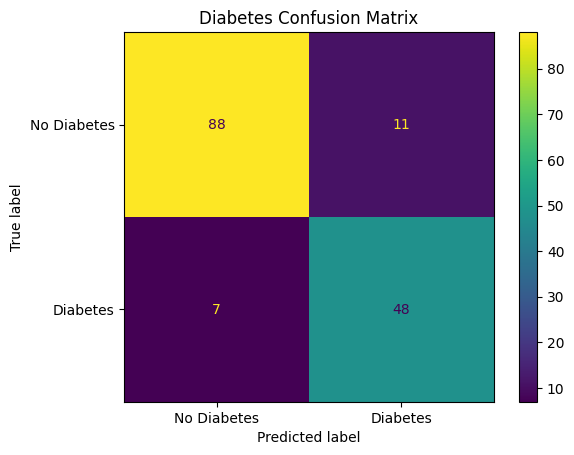

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Diabetes", "Diabetes"])

disp.plot()

plt.title("Diabetes Confusion Matrix")

plt.savefig("../outputs/diabetes_confusion_matrix.png")

plt.show()

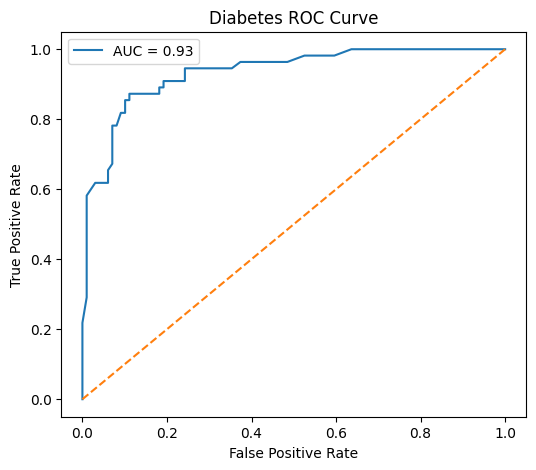

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Diabetes ROC Curve")
plt.legend()

plt.savefig("../outputs/diabetes_roc_curve.png")

plt.show()

In [33]:
print(X.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')


In [ ]:
print(type(model))